In [1]:
import sys
from pathlib import Path
import os
import pandas as pd
sys.path.append(str(Path.cwd().parent))
DATA_DIR = os.path.join(os.getcwd(), "..", "data")

In [ ]:
from src.load_data import get_moex_candles, save_candles_df
from datetime import datetime
start_date = datetime(2013, 1, 1)
end_date = datetime(2026, 3, 15)
ticker = "IMOEX"

candles = get_moex_candles(ticker, start_date, end_date, rest_time=0.5, interval=10, market="index")
save_candles_df(candles, "IMOEX.csv")

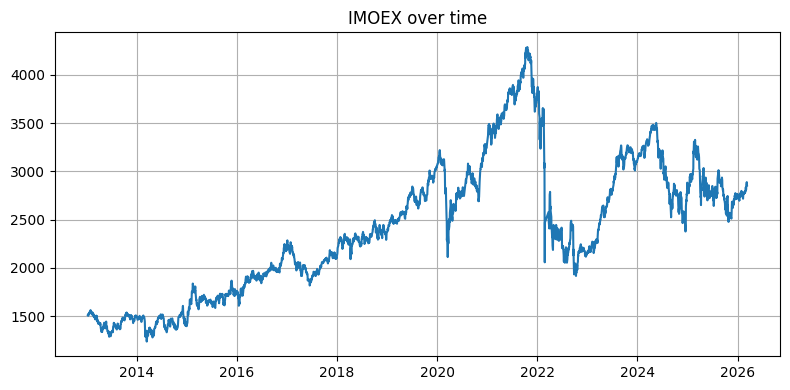

In [2]:
candles = pd.read_csv(os.path.join(DATA_DIR, "IMOEX.csv"))
candles['end'] = pd.to_datetime(candles['end'])
candles.set_index('end', inplace=True)
candles = candles.resample("D").agg({
    'open': 'first',
    'high': 'max',
    'low': 'min',
    'close': 'last',
    'volume': 'sum'  
}).dropna()

from matplotlib import pyplot as plt
plt.figure(figsize=(8, 4))
plt.plot(candles.index, candles['close'])
plt.title("IMOEX over time")
plt.grid()
plt.tight_layout()

In [3]:
from src.get_features import add_log_returns, add_volatility, add_drawdown_features

candles = add_log_returns(candles, [1, 7, 14, 30, 90])
candles = add_volatility(candles, [7, 14, 30, 90])
candles = add_drawdown_features(candles, [7, 14, 30, 90, 180])

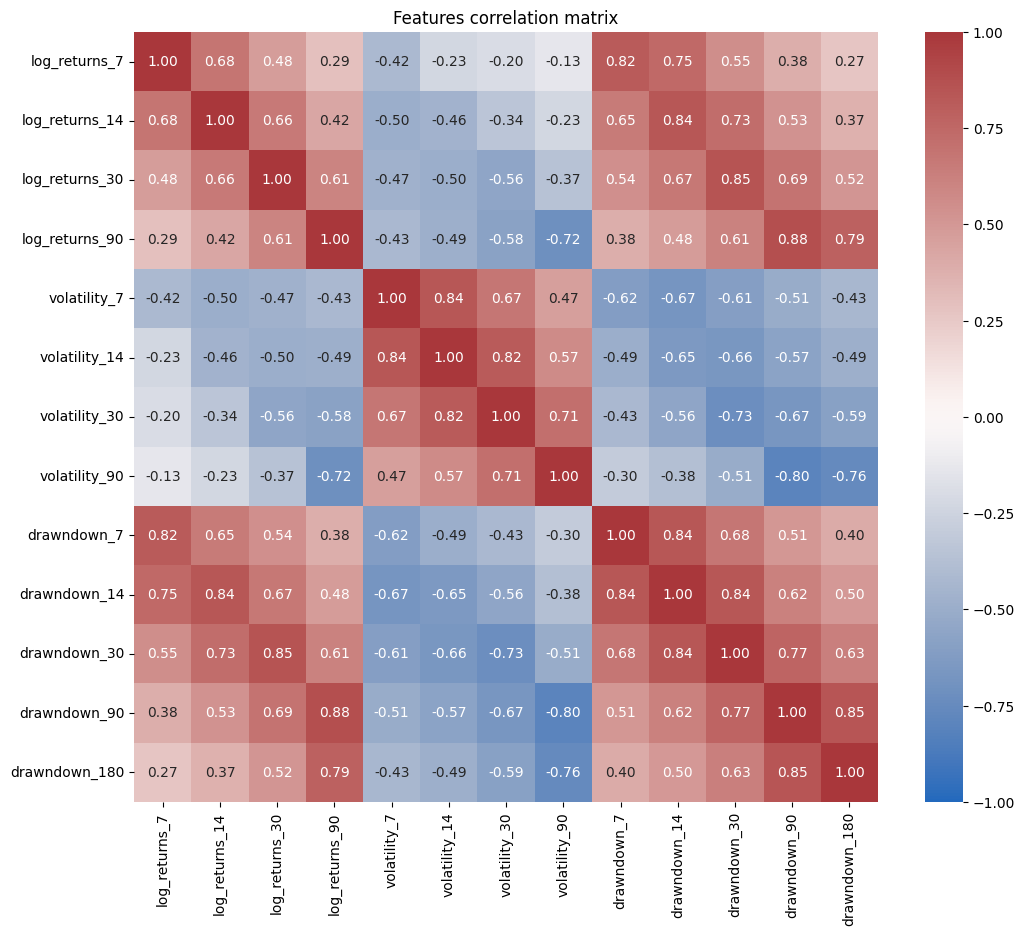

In [5]:
import seaborn as sns

features = [
    "log_returns_7", "log_returns_14", "log_returns_30", "log_returns_90",
    "volatility_7", "volatility_14", "volatility_30", "volatility_90", 
    "drawndown_7", "drawndown_14", "drawndown_30", "drawndown_90", "drawndown_180"
]
features_df = candles[features].dropna()
correlation_matrix_pd = features_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix_pd, annot=True, cmap="vlag", fmt=".2f", center=0, vmin=-1, vmax=1)
plt.title("Features correlation matrix")
plt.show()

Model is not converging.  Current: 82561.39561102989 is not greater than 82561.62031266477. Delta is -0.22470163488469552
Model is not converging.  Current: 83537.9187244992 is not greater than 83537.92827664006. Delta is -0.009552140851155855
Model is not converging.  Current: 84198.60477572423 is not greater than 84198.72270473567. Delta is -0.1179290114378091
Model is not converging.  Current: 83878.35113967163 is not greater than 83878.4207837195. Delta is -0.0696440478641307
Model is not converging.  Current: 84792.62545857175 is not greater than 84850.77725598904. Delta is -58.151797417289345
Model is not converging.  Current: 86194.30261985771 is not greater than 86194.30643521596. Delta is -0.003815358242718503
Model is not converging.  Current: 85527.15430231273 is not greater than 85592.63984707344. Delta is -65.48554476071149
Model is not converging.  Current: 85519.9990408674 is not greater than 85616.58489011302. Delta is -96.58584924561728
Model is not converging.  Curren

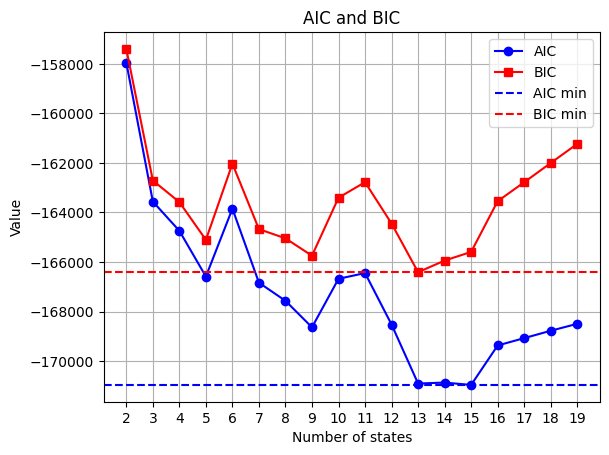

In [6]:
from src.train_hmm import train_hmm
features = [
    "log_returns_7", "log_returns_14", "log_returns_30", "log_returns_90",
    "volatility_7", "volatility_14", "volatility_30", "volatility_90"
]

candles = candles.dropna()
X = candles[features].values

bics = []
aics = []
ks = range(2, 20)
for k in ks:
    model = train_hmm(X, n_states=k, n_iter=5000)
    bics.append(model.bic(X))
    aics.append(model.aic(X))

plt.plot(ks, aics, marker='o', label='AIC', color='blue')
plt.plot(ks, bics, marker='s', label='BIC', color='red')

min_aic = min(aics)
min_bic = min(bics)
plt.axhline(min_aic, linestyle='--', label='AIC min', color='blue')
plt.axhline(min_bic, linestyle='--', label='BIC min', color='red')

plt.xlabel('Number of states')
plt.ylabel('Value')
plt.title('AIC and BIC')
plt.grid()
plt.xticks(ks)
plt.legend()
plt.show()

In [17]:
model = train_hmm(X, n_states=8, n_iter=5000)

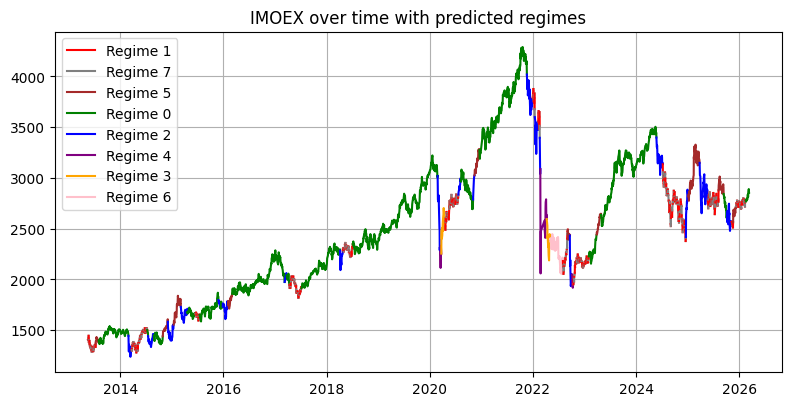

In [18]:
from src.visualization import plot_price_with_regimes
regimes = model.predict(X)
dates = candles.index
prices = candles['close'].values

plot_price_with_regimes(prices, dates, regimes)

In [19]:
candles['regime'] = regimes
statistics = candles.groupby('regime').agg({
    'log_returns_7': ['mean', 'std'],
    'volatility_7': ['mean', 'std'],
    'close':['count']
})

print(statistics)

       log_returns_7           volatility_7           close
                mean       std         mean       std count
regime                                                     
0           0.004198  0.022822     0.008101  0.003109  1849
1           0.001797  0.031415     0.011185  0.004589   325
2          -0.017617  0.062141     0.019066  0.010200   349
3          -0.000843  0.079531     0.025802  0.010684    36
4          -0.090227  0.190326     0.073525  0.065283    26
5           0.021909  0.031161     0.011966  0.004488   253
6          -0.008554  0.044996     0.018477  0.006563    60
7           0.000176  0.031580     0.011124  0.004626   322


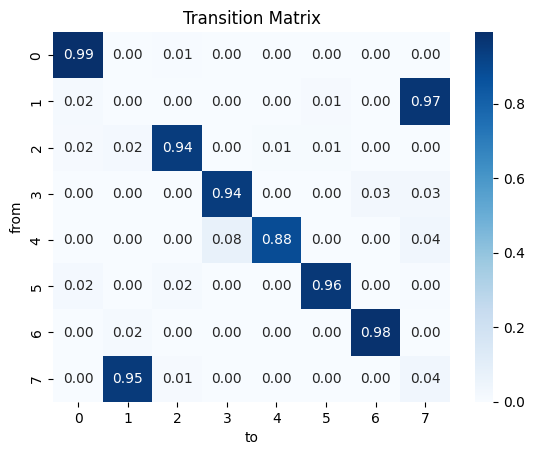

In [20]:
import seaborn as sns
sns.heatmap(model.transmat_, annot=True, cmap="Blues", fmt=".2f")
plt.title("Transition Matrix")
plt.xlabel("to")
plt.ylabel("from")
plt.show()

In [21]:
import numpy as np
trans = model.transmat_
expected_duration = 1 / (1 - np.diag(trans))
df = pd.DataFrame({
    "Stay Probability": np.diag(trans),
    "Expected regime duration (days)": np.round(expected_duration, 2)
})
print(df)

   Stay Probability  Expected regime duration (days)
0          0.991633                           119.51
1          0.000002                             1.00
2          0.944237                            17.93
3          0.944432                            18.00
4          0.884462                             8.66
5          0.960243                            25.15
6          0.983333                            60.00
7          0.035504                             1.04


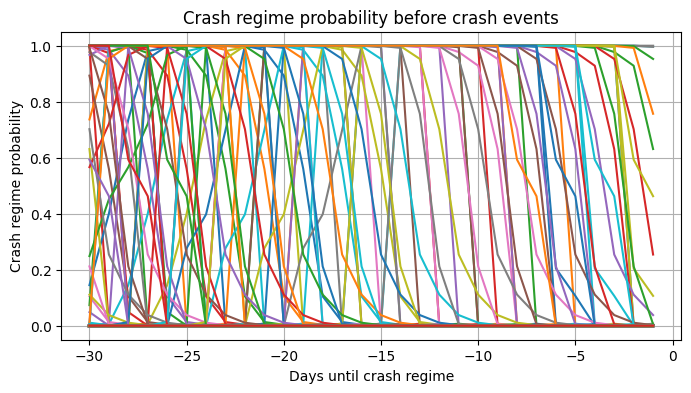

In [22]:
crash_regime = 2
probs = model.predict_proba(X)
crash_prob = probs[:, crash_regime]
candles["crash_prob"] = crash_prob

plt.figure(figsize=(8, 4))
crash_starts = []
for i in range(1, len(regimes)):
    if regimes[i] == 1 and regimes[i-1] != 1:
        crash_starts.append(i)

window = 30
for index in crash_starts:
    start = max(0, index-window)
    end = index
    
    plt.plot(range(-(end-start), 0), crash_prob[start:end])

plt.xlabel("Days until crash regime")
plt.ylabel("Crash regime probability")
plt.title("Crash regime probability before crash events")
plt.grid()

plt.show()